In [11]:
import pandas as pd

df = pd.read_csv('fitts_study_exp_hand.csv')
df.head()

,idx,target_size,target_distance,reaction_time
0,1,43.246365,208.566240,732.0
1,2,52.988552,224.794830,532.0
2,3,43.444454,351.376100,700.0
3,4,15.245137,434.747100,1001.0
4,5,33.151085,97.752556,633.0


In [12]:
# compute difficulty based on fitts law

import numpy as np

df["difficulty"] = np.log2((df["target_distance"] / df["target_size"]) + 1)

df.head()

,idx,target_size,target_distance,reaction_time,difficulty
0,1,43.246365,208.566240,732.0,2.541700
1,2,52.988552,224.794830,532.0,2.390208
2,3,43.444454,351.376100,700.0,3.183953
3,4,15.245137,434.747100,1001.0,4.883479
4,5,33.151085,97.752556,633.0,1.981377


In [13]:
# remove outliers based on reaction time
df = df[df["reaction_time"] < 1500]

Text(0.5, 1.0, 'Difficulty vs Reaction Time')

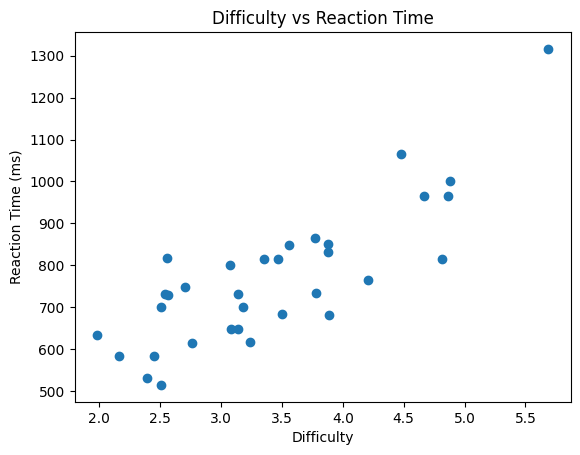

In [14]:
# plot scatter plot of difficulty vs movement time

import matplotlib.pyplot as plt
plt.scatter(df["difficulty"], df["reaction_time"])
plt.xlabel("Difficulty")
plt.ylabel("Reaction Time (ms)")
plt.title("Difficulty vs Reaction Time")

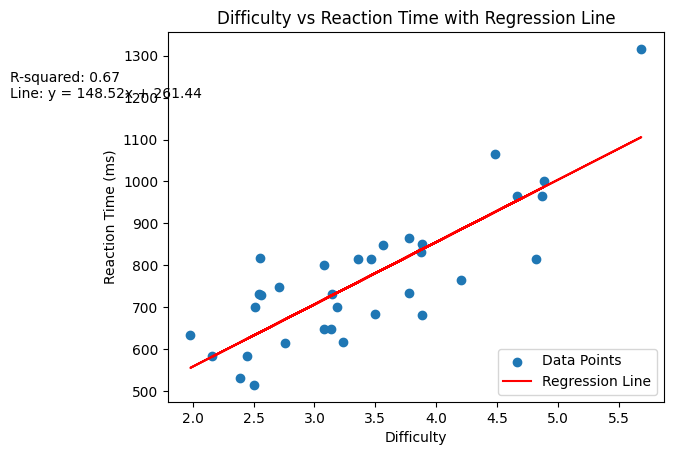

In [15]:
# plot linear regression line
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(df["difficulty"], df["reaction_time"])
# plot regression line and scatter plot together
plt.scatter(df["difficulty"], df["reaction_time"], label="Data Points")
plt.plot(df["difficulty"], intercept + slope*df["difficulty"], 'r', label="Regression Line")
plt.xlabel("Difficulty")
plt.ylabel("Reaction Time (ms)")
plt.title("Difficulty vs Reaction Time with Regression Line")
plt.legend()

# show R-squared value and line equation on the plot
plt.text(0.5, 1200, f'R-squared: {r_value**2:.2f}\nLine: y = {slope:.2f}x + {intercept:.2f}', fontsize=10)
plt.show()

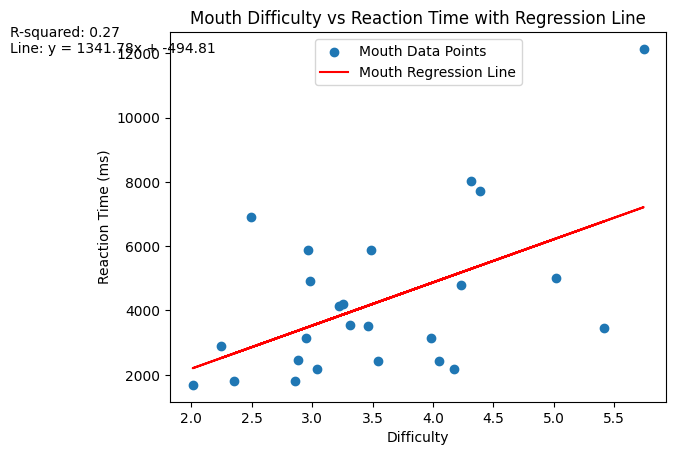

In [16]:
# add the same analysis for the mouth data
df_mouth = pd.read_csv('fitts_study_exp_mouth.csv')
df_mouth["difficulty"] = np.log2((df_mouth["target_distance"] / df_mouth["target_size"]) + 1)
df_mouth = df_mouth[df_mouth["reaction_time"] < 15000]
slope_mouth, intercept_mouth, r_value_mouth, p_value_mouth, std_err_mouth = stats.linregress(df_mouth["difficulty"], df_mouth["reaction_time"])
plt.scatter(df_mouth["difficulty"], df_mouth["reaction_time"], label="Mouth Data Points")
plt.plot(df_mouth["difficulty"], intercept_mouth + slope_mouth*df_mouth["difficulty"], 'r', label="Mouth Regression Line")
plt.xlabel("Difficulty")
plt.ylabel("Reaction Time (ms)")
plt.title("Mouth Difficulty vs Reaction Time with Regression Line")
plt.legend()
plt.text(0.5, 12000, f'R-squared: {r_value_mouth**2:.2f}\nLine: y = {slope_mouth:.2f}x + {intercept_mouth:.2f}', fontsize=10)
plt.show()

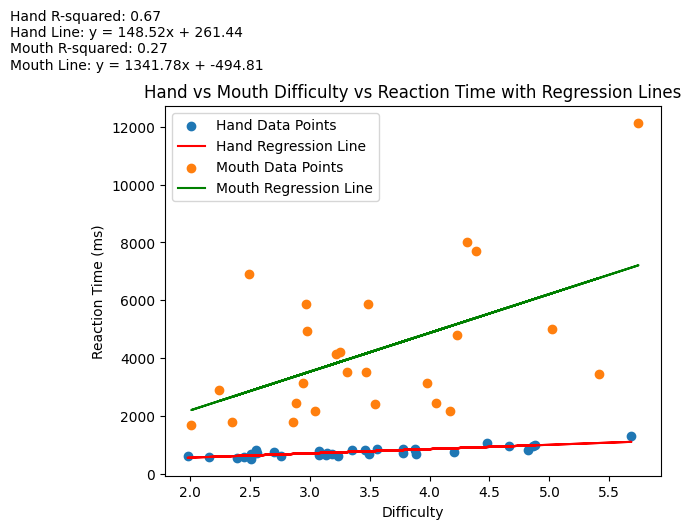

In [18]:
# plot the hand and mouth data on the same plot for comparison
plt.scatter(df["difficulty"], df["reaction_time"], label="Hand Data Points")
plt.plot(df["difficulty"], intercept + slope*df["difficulty"], 'r', label="Hand Regression Line")
plt.scatter(df_mouth["difficulty"], df_mouth["reaction_time"], label="Mouth Data Points")
plt.plot(df_mouth["difficulty"], intercept_mouth + slope_mouth*df_mouth["difficulty"], 'g', label="Mouth Regression Line")
plt.xlabel("Difficulty")
plt.ylabel("Reaction Time (ms)")
plt.title("Hand vs Mouth Difficulty vs Reaction Time with Regression Lines")
plt.legend()
plt.text(0.5, 14000, f'Hand R-squared: {r_value**2:.2f}\nHand Line: y = {slope:.2f}x + {intercept:.2f}\nMouth R-squared: {r_value_mouth**2:.2f}\nMouth Line: y = {slope_mouth:.2f}x + {intercept_mouth:.2f}', fontsize=10)
plt.show()